# Modeling Notebook Overview

This notebook focuses on building, tuning, and preparing machine‑learning models for predicting customer churn. The goal is not only to train several model families, but also to evaluate their performance on a validation set, optimize their decision thresholds, and save the final versions for later use in the evaluation notebook.

Because churn prediction is a business‑critical task, the modeling process emphasizes interpretability, robustness, and fairness rather than simply maximizing accuracy.

### Class Imbalance

The target variable Churn is imbalanced, with far more customers staying than leaving.
This imbalance affects both training and evaluation:

- Accuracy becomes misleading  
A model predicting “no churn” for everyone would achieve high accuracy but be useless.

- Alternative metrics are required  
Precision, recall, F1‑score, and ROC‑AUC provide a more meaningful assessment.

- Model adjustments help mitigate imbalance

    - Logistic Regression: class_weight="balanced"

    - Random Forest: class‑balanced sampling

    - XGBoost: scale_pos_weight (implicitly handled through tuning)

- Threshold tuning is essential  
The default threshold of 0.5 rarely maximizes recall for churners.
Lowering the threshold typically increases the model’s ability to catch churners, which is often the most important business objective.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import joblib


## 1. Load Preprocessed Data

In [2]:
df = pd.read_csv("../data/PreprocessedData.csv").copy()

## 2. Train/Val/Test Split

In [3]:
y = df["Churn"]
X = df.drop("Churn", axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=22, stratify=y_train)

## 3. Preprocessing Pipeline
A ColumnTransformer is used to:

- Scale numerical features using StandardScaler

- One‑hot encode categorical features using OneHotEncoder

- Pass through any remaining columns unchanged

This ensures that all models receive the same processed feature matrix.

In [4]:
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChargeTenureInteraction",
    "TotalServiceCount",
    "HouseholdSize"
]

categorical_cols = [col for col in X.columns if X[col].dtype == "object"]


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

## 4. Evaluation Function

The evaluate() function computes key performance metrics:

- Precision
- Recall
- F1‑score
- ROC‑AUC

These metrics allow consistent comparison across models and tuning stages.

In [ ]:
def evaluate(model, X_val, y_val):
    pred = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]

    return {
        "precision": precision_score(y_val, pred),
        "recall": recall_score(y_val, pred),
        "f1": f1_score(y_val, pred),
        "roc_auc": roc_auc_score(y_val, proba)
    }

## 5. Confusion Matrix Plot Function

In [6]:
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 6. Logistic Regression

### 6.1 Baseline Model

Logistic Regression serves as the baseline model because:

- It is interpretable

- It handles linear relationships well

- It provides calibrated probabilities

- It is commonly used in churn prediction

The baseline model uses default hyperparameters and the preprocessing pipeline.

In [7]:
baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("clf", LogisticRegression(max_iter=500))
])

baseline_model.fit(X_train, y_train)

results = {}
results["log_reg_default"] = evaluate(baseline_model, X_val, y_val)


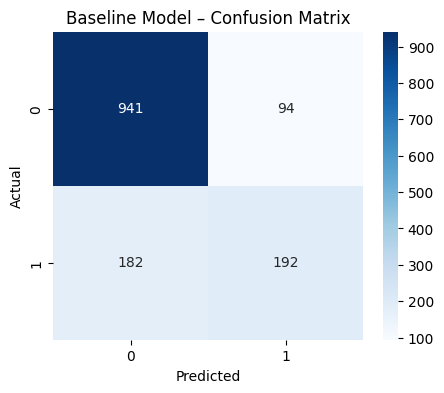

In [8]:
baseline_preds = baseline_model.predict(X_val)
plot_conf_matrix(y_val, baseline_preds, title="Baseline Model – Confusion Matrix")

### 6.2 Hyperparameter Tuning

A grid search with 5‑fold cross‑validation is used to tune:

- Regularization strength C

- Penalty type (l1, l2)

- Solver

- Class weighting

The model is selected based on the average precision score, since the data is imbalanced. 

In [9]:
lr_param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"],
    "clf__class_weight": ["balanced", None]
}

grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=lr_param_grid,
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best CV score: 0.6494541261471388


In [10]:
best_model = grid_search.best_estimator_

results["log_reg_tuned"] = evaluate(best_model, X_val, y_val)

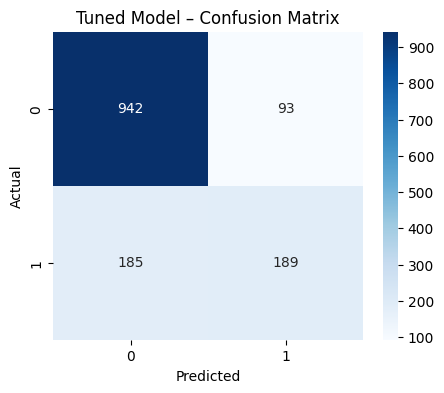

In [11]:
tuned_preds = best_model.predict(X_val)
plot_conf_matrix(y_val, tuned_preds, title="Tuned Model – Confusion Matrix")


### 6.3 Threshold Tuning
The default classification threshold (0.5) is rarely optimal for imbalanced problems.

In [12]:
proba = best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)
scores = []

for t in thresholds:
    preds = (proba >= t).astype(int)
    scores.append(f1_score(y_val, preds))

best_t = thresholds[np.argmax(scores)]
print("Best threshold:", best_t)

#evaluate threshold

best_preds = (proba >= best_t).astype(int)

print("F1:", f1_score(y_val, best_preds))
print("Recall:", recall_score(y_val, best_preds))

Best threshold: 0.37755102040816324
F1: 0.6372795969773299
Recall: 0.6764705882352942


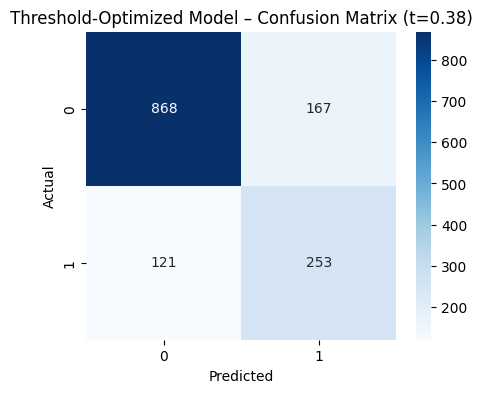

In [13]:
threshold_preds = (proba >= best_t).astype(int)
plot_conf_matrix(y_val, threshold_preds, title=f"Threshold-Optimized Model – Confusion Matrix (t={best_t:.2f})")


In [14]:
results_df = pd.DataFrame(results).T
print(results_df)

                 precision    recall        f1   roc_auc
log_reg_default   0.671329  0.513369  0.581818  0.843225
log_reg_tuned     0.670213  0.505348  0.576220  0.843210


## 7. Random Forest

### 7.1 Baseline Model

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions.

It is included because:

- It can capture non-linear relationships and feature interactions  
- It is robust to noise and overfitting due to averaging across trees  
- It requires minimal preprocessing compared to linear models  

However, it is less interpretable than Logistic Regression, which can be a limitation in business contexts.

In [24]:
rf_baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("rfc", RandomForestClassifier())
])

rf_baseline_model.fit(X_train, y_train)
results["rf_default"] = evaluate(rf_baseline_model, X_val, y_val)

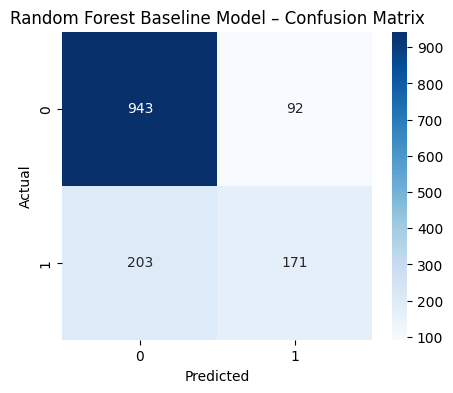

In [25]:
rf_baseline_preds = rf_baseline_model.predict(X_val)
plot_conf_matrix(y_val, rf_baseline_preds, title="Random Forest Baseline Model – Confusion Matrix")

### 7.2 Hyperparameter Tuning

To improve model performance, a grid search with cross-validation is applied to the Random Forest model.

The tuning focuses on key parameters that control model complexity and generalization:

- Number of trees (n_estimators)
- Maximum tree depth (max_depth)
- Minimum samples required to split a node (min_samples_split)
- Number of features considered at each split (max_features)

As with Logistic Regression, the model is evaluated using average precision to better reflect performance on imbalanced data.

In [ ]:
rf_param_grid = {
    "rfc__n_estimators": [10, 50, 100, 150, 200],
    "rfc__max_depth": [10, 20, None],
    "rfc__min_samples_split": [2, 5, 10],
    "rfc__max_features": ["sqrt", "log2", None]
}

rf_grid_search = GridSearchCV(
    estimator=rf_baseline_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print("Best params:", rf_grid_search.best_params_)
print("Best CV score:", rf_grid_search.best_score_)


Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best params: {'rfc__max_depth': 10, 'rfc__max_features': 'log2', 'rfc__min_samples_split': 10, 'rfc__n_estimators': 200}
Best CV score: 0.6548267999021912


In [45]:
rf_best_model = rf_grid_search.best_estimator_

results["rf_tuned"] = evaluate(rf_best_model, X_val, y_val)

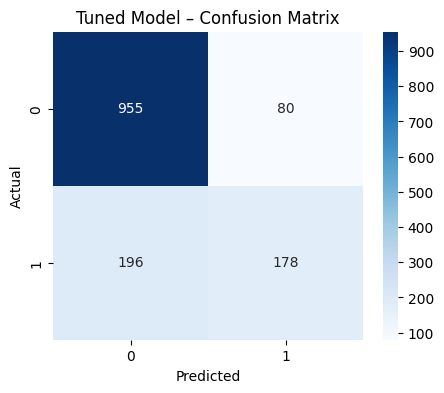

In [46]:
rf_tuned_preds = rf_best_model.predict(X_val)
plot_conf_matrix(y_val, rf_tuned_preds, title="Tuned Model – Confusion Matrix")


### 7.3 Threshold Tuning

Similar to Logistic Regression, the classification threshold is optimized to improve the balance between precision and recall.

Since detecting churners is typically more important than avoiding false positives, lowering the threshold can improve recall and overall business value.

In [76]:
proba = rf_best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)
scores = []

for t in thresholds:
    preds = (proba >= t).astype(int)
    scores.append(f1_score(y_val, preds))

rf_best_t = thresholds[np.argmax(scores)]
print("Best threshold:", rf_best_t)

#evaluate threshold

best_preds = (proba >= rf_best_t).astype(int)

print("F1:", f1_score(y_val, best_preds))
print("Recall:", recall_score(y_val, best_preds))

Best threshold: 0.36122448979591837
F1: 0.6335403726708074
Recall: 0.6818181818181818


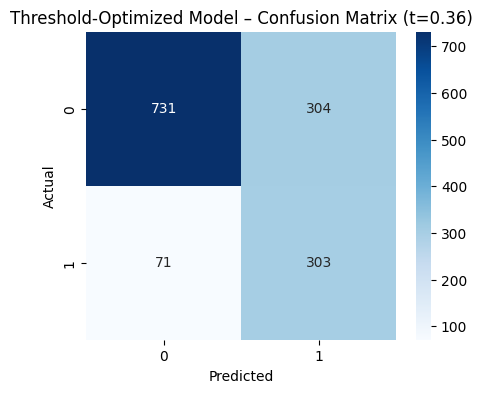

In [77]:
threshold_preds = (proba >= best_t).astype(int)
plot_conf_matrix(y_val, threshold_preds, title=f"Threshold-Optimized Model – Confusion Matrix (t={rf_best_t:.2f})")


In [31]:
results_df = pd.DataFrame(results).T
print(results_df)

                 precision    recall        f1   roc_auc
log_reg_default   0.671329  0.513369  0.581818  0.843225
log_reg_tuned     0.670213  0.505348  0.576220  0.843210
rf_tuned          0.689922  0.475936  0.563291  0.846533
rf_default        0.650190  0.457219  0.536892  0.829360


## 8. XGBoost

XGBoost is a powerful gradient boosting algorithm that often performs well on structured/tabular data.

It is included in this analysis because:

- It can capture complex, non-linear relationships
- It includes built-in regularization to prevent overfitting
- It often achieves strong predictive performance in churn problems

However, compared to Logistic Regression, it is less interpretable, which is an important trade-off in business applications.

### 8.1 Baseline Model

In [42]:
xgb_baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        max_depth=3,
        learning_rate=0.1,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

xgb_baseline_model.fit(X_train, y_train)

results["xgb_default"] = evaluate(xgb_baseline_model, X_val, y_val)

c:\Users\marle\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:25:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


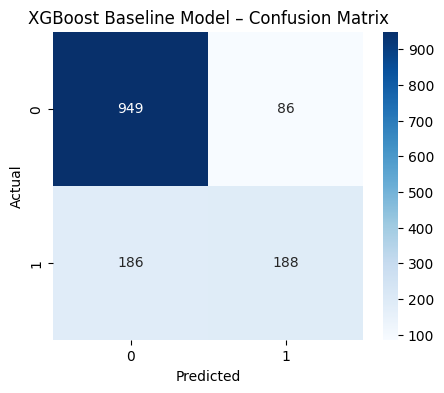

In [43]:
xgb_baseline_preds = xgb_baseline_model.predict(X_val)
plot_conf_matrix(y_val, xgb_baseline_preds, title="XGBoost Baseline Model – Confusion Matrix")

### 8.2 Hyperparameter Tuning

Grid search is used to tune key XGBoost parameters:

- Number of boosting rounds (n_estimators)
- Tree depth (max_depth)
- Learning rate
- Subsampling ratios (subsample, colsample_bytree)

These parameters control the balance between model complexity, learning speed, and generalization performance.

In [47]:
xgb_param_grid = {
    "xgb__n_estimators": [100, 200],
    "xgb__max_depth": [3, 5],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_baseline_model,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

print("Best params:", xgb_grid_search.best_params_)
print("Best CV score:", xgb_grid_search.best_score_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}
Best CV score: 0.6630564422337387


c:\Users\marle\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:29:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [49]:
xgb_best_model = xgb_grid_search.best_estimator_

results["xgb_tuned"] = evaluate(xgb_best_model, X_val, y_val)

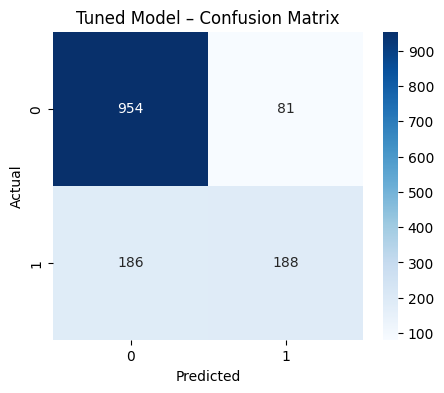

In [50]:
xgb_tuned_preds = xgb_best_model.predict(X_val)
plot_conf_matrix(y_val, xgb_tuned_preds, title="Tuned Model – Confusion Matrix")


### 8.3 Threshold Tuning

As with the other models, the decision threshold is optimized based on the validation set.

This step is particularly important for boosting models, as they often produce well-ranked probabilities that benefit significantly from threshold adjustment.

In [75]:
proba = xgb_best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)
scores = []

for t in thresholds:
    preds = (proba >= t).astype(int)
    scores.append(f1_score(y_val, preds))

xgb_best_t = thresholds[np.argmax(scores)]
print("Best threshold:", xgb_best_t)

#evaluate threshold

best_preds = (proba >= xgb_best_t).astype(int)

print("F1:", f1_score(y_val, best_preds))
print("Recall:", recall_score(y_val, best_preds))

Best threshold: 0.2306122448979592
F1: 0.6323232323232323
Recall: 0.8368983957219251


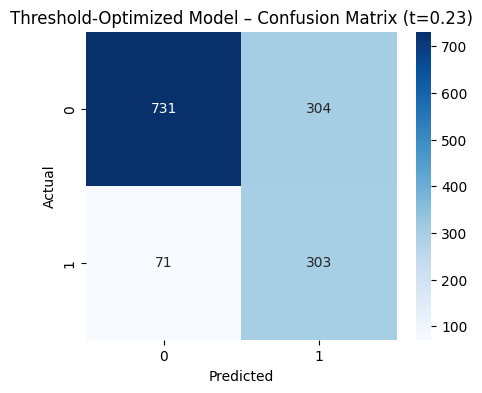

In [79]:
threshold_preds = (proba >= best_t).astype(int)
plot_conf_matrix(y_val, threshold_preds, title=f"Threshold-Optimized Model – Confusion Matrix (t={xgb_best_t:.2f})")


In [54]:
results_df = pd.DataFrame(results).T
print(results_df)

                 precision    recall        f1   roc_auc
log_reg_default   0.671329  0.513369  0.581818  0.843225
log_reg_tuned     0.670213  0.505348  0.576220  0.843210
rf_tuned          0.689922  0.475936  0.563291  0.846533
rf_default        0.650190  0.457219  0.536892  0.829360
xgb_default       0.686131  0.502674  0.580247  0.851985
xgb_tuned         0.698885  0.502674  0.584759  0.852507


## 9. Saving Models and Thresholds

In [69]:
joblib.dump(best_model, "logreg_best_model.pkl")
joblib.dump(rf_best_model, "rf_best_model.pkl")
joblib.dump(xgb_best_model, "xgb_best_model.pkl")

['xgb_best_model.pkl']

In [78]:
joblib.dump(best_t, "logreg_best_threshold.pkl")
joblib.dump(rf_best_t, "rf_best_threshold.pkl")
joblib.dump(xgb_best_t, "xgb_best_threshold.pkl")


['xgb_best_threshold.pkl']

## Summary and Key Takeaways
In this notebook, multiple machine learning models were developed and evaluated for customer churn prediction.

### Key steps included:

- Building baseline models for Logistic Regression, Random Forest, and XGBoost
- Performing hyperparameter tuning using cross-validation
- Evaluating models using appropriate metrics for imbalanced data
- Optimizing classification thresholds to improve business relevance
- Saving final models for downstream evaluation

### Key insights:

- XGBoost achieved the strongest overall performance, with the highest ROC-AUC (~0.85) and the best balance between precision and F1-score among all models  

- Hyperparameter tuning had a limited impact on Logistic Regression, with performance remaining largely unchanged, suggesting that the baseline model was already close to optimal  

- In contrast, Random Forest benefited more from tuning, improving across all metrics compared to its baseline version  

- XGBoost tuning resulted in modest but consistent improvements, particularly in precision and overall ranking performance (ROC-AUC)  

- Across all models, recall remained around ~0.45–0.51 at the default threshold, confirming that threshold tuning is necessary to better capture churners  

- Logistic Regression performed competitively with more complex models, especially in terms of recall, while remaining the most interpretable option  

- Overall, tree-based models (especially XGBoost) provided the best predictive performance, but the improvement over Logistic Regression was moderate, highlighting a trade-off between performance gains and interpretability  

- From a business perspective, the relatively small performance gap between models suggests that model selection should also consider interpretability, operational complexity, and ease of deployment.

### Next steps:

The saved models will be evaluated on the unseen test set in the evaluation notebook.  
This will provide a final, unbiased estimate of model performance and support model selection for deployment.